In [ ]:
!pip install web3 --quiet

import os
import json
import hashlib
import pandas as pd
import numpy as np
from datetime import datetime
from web3 import Web3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.5/587.5 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.4/51.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.3/340.3 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 112.3 MB/s eta 0:00:00


In [ ]:
csv_paths = {
    "Random Forest"            : "/content/RandomForest_overall_attack_summary.csv",
    "CoAtNet + Self-Attention" : "/content/CoAtNet_SelfAttn_overall_attack_summary.csv",
    "CoAtNet"                  : "/content/CoAtNet_overall_attack_summary.csv",
    "LSTM"                     : "/content/LSTM_overall_attack_summary.csv",
    "Skypetype"                : "/content/Skypetype_overall_attack_summary.csv",
    "SVM"                      : "/content/SVM_overall_attack_summary.csv",
    "LogMel CNN"               : "/content/LogMel_CNN_overall_attack_summary.csv",
}

In [ ]:
required_cols = {
    "model_name", "Clean accuracy", "attack type",
    "epsilon", "adversarial accuracy", "relative accuracy", "ASR"
}

all_frames = []

for model_label, path in csv_paths.items():

    if not os.path.exists(path):
        print(f"  [WARNING] Not found : {path}")
        print(f"            Skipping  : {model_label}")
        continue

    df = pd.read_csv(path)

    missing = required_cols - set(df.columns)
    if missing:
        print(f"  [WARNING] {model_label} missing columns {missing} — skipping")
        continue

    df["model_name"] = model_label      # enforce canonical label
    all_frames.append(df)
    print(f"  [OK] {model_label:<35}  rows = {len(df)}")

if not all_frames:
    raise RuntimeError("No valid CSVs loaded. Check the paths in csv_paths above.")

df_all = pd.concat(all_frames, ignore_index=True)
df_all["epsilon"] = df_all["epsilon"].astype(float)

print(f"\n  Total rows loaded  : {len(df_all)}")
print(f"  Models loaded      : {df_all['model_name'].nunique()}")
print(f"  Attack types found : {sorted(df_all['attack type'].unique())}")

  [OK] Random Forest                        rows = 4
  [OK] CoAtNet + Self-Attention             rows = 16
  [OK] CoAtNet                              rows = 16
  [OK] LSTM                                 rows = 16
  [OK] Skypetype                            rows = 4
  [OK] SVM                                  rows = 4
  [OK] LogMel CNN                           rows = 16

  Total rows loaded  : 76
  Models loaded      : 7
  Attack types found : ['BIM', 'DFT-Random', 'FGSM', 'PGD']


In [ ]:
summary = (
    df_all
    .groupby("model_name")
    .agg(
        clean_accuracy       = ("Clean accuracy",       "first"),
        mean_adv_accuracy    = ("adversarial accuracy",  "mean"),
        mean_relative_acc    = ("relative accuracy",     "mean"),
        mean_asr             = ("ASR",                   "mean"),
        min_adv_accuracy     = ("adversarial accuracy",  "min"),
        max_asr              = ("ASR",                   "max"),
    )
    .reset_index()
)

# Robustness score: high clean accuracy + low mean ASR = best model
summary["robustness_score"] = summary["clean_accuracy"] - summary["mean_asr"]

summary = summary.sort_values("robustness_score", ascending=False).reset_index(drop=True)
summary["rank"] = summary.index + 1

In [ ]:
best_row   = summary.iloc[0]
best_model = best_row["model_name"]

# Robustness Score = Clean - Mean ASR
print(f"  {'Rank':<5} {'Model':<30} {'CleanAcc':>9} {'MeanAdvAcc':>11} {'MeanASR':>8} {'RobScore':>9}")
print("  " + "-" * 66)

for _, row in summary.iterrows():
    marker = "BEST" if row["model_name"] == best_model else ""
    print(
        f"  {int(row['rank']):<5} "
        f"{row['model_name']:<30} "
        f"{row['clean_accuracy']:>8.2f}% "
        f"{row['mean_adv_accuracy']:>10.2f}% "
        f"{row['mean_asr']:>7.2f}% "
        f"{row['robustness_score']:>8.2f}%"
        f"{marker}"
    )

  Rank  Model                           CleanAcc  MeanAdvAcc  MeanASR  RobScore
  ------------------------------------------------------------------
  1     LSTM                              91.81%      91.38%    0.48%    91.33%BEST
  2     CoAtNet                           97.81%      89.54%    8.46%    89.35%
  3     Skypetype                         95.75%      81.20%   15.19%    80.56%
  4     CoAtNet + Self-Attention          96.00%      71.17%   25.86%    70.14%
  5     SVM                               96.06%      58.50%   39.10%    56.96%
  6     Random Forest                     90.62%      57.30%   36.78%    53.84%
  7     LogMel CNN                        67.38%      48.17%   28.51%    38.87%


In [ ]:
df_best = df_all[df_all["model_name"] == best_model].copy()

print(f"  BEST MODEL  :  {best_model}")
print(f"  Clean Accuracy     : {best_row['clean_accuracy']:.2f}%")
print(f"  Mean Adv Accuracy  : {best_row['mean_adv_accuracy']:.2f}%")
print(f"  Mean Rel Accuracy  : {best_row['mean_relative_acc']:.2f}%")
print(f"  Mean ASR           : {best_row['mean_asr']:.2f}%")
print(f"  Worst Adv Accuracy : {best_row['min_adv_accuracy']:.2f}%")
print(f"  Worst-Case ASR     : {best_row['max_asr']:.2f}%")
print(f"  Robustness Score   : {best_row['robustness_score']:.2f}%")

print(f"\n  {'Attack Type':<18} {'ε':>7} {'CleanAcc':>9} {'AdvAcc':>8} {'RelAcc':>8} {'ASR':>8}")

for _, row in df_best.sort_values(["attack type", "epsilon"]).iterrows():
    print(
        f"  {row['attack type']:<18} "
        f"{row['epsilon']:>7.3f} "
        f"{row['Clean accuracy']:>8.2f}% "
        f"{row['adversarial accuracy']:>7.2f}% "
        f"{row['relative accuracy']:>7.2f}% "
        f"{row['ASR']:>7.2f}%"
    )

  BEST MODEL  :  LSTM
  Clean Accuracy     : 91.81%
  Mean Adv Accuracy  : 91.38%
  Mean Rel Accuracy  : 99.52%
  Mean ASR           : 0.48%
  Worst Adv Accuracy : 90.38%
  Worst-Case ASR     : 1.56%
  Robustness Score   : 91.33%

  Attack Type              ε  CleanAcc   AdvAcc   RelAcc      ASR
  BIM                  0.005    91.81%   91.63%   99.80%    0.20%
  BIM                  0.010    91.81%   91.50%   99.66%    0.34%
  BIM                  0.020    91.81%   91.31%   99.45%    0.55%
  BIM                  0.050    91.81%   90.38%   98.44%    1.56%
  DFT-Random           0.005    91.81%   91.81%  100.00%    0.00%
  DFT-Random           0.010    91.81%   91.81%  100.00%    0.00%
  DFT-Random           0.020    91.81%   91.81%  100.00%    0.00%
  DFT-Random           0.050    91.81%   91.81%  100.00%    0.00%
  FGSM                 0.005    91.81%   91.63%   99.80%    0.20%
  FGSM                 0.010    91.81%   91.50%   99.66%    0.34%
  FGSM                 0.020    91.81%   91

In [ ]:
print("  MEAN ASR PER ATTACK TYPE — ALL MODELS")

attack_pivot = (
    df_all
    .groupby(["model_name", "attack type"])["ASR"]
    .mean()
    .unstack(fill_value=0)
    .round(2)
)

attack_pivot.insert(0, "Clean Acc",
    df_all.groupby("model_name")["Clean accuracy"].first())
attack_pivot.insert(0, "Rank",
    summary.set_index("model_name")["rank"])
attack_pivot = attack_pivot.loc[summary["model_name"]]

print(attack_pivot.to_string())

  MEAN ASR PER ATTACK TYPE — ALL MODELS
attack type               Rank  Clean Acc    BIM  DFT-Random   FGSM    PGD
model_name                                                                
LSTM                         1      91.81   0.66        0.00   0.60   0.64
CoAtNet                      2      97.81  15.51       -0.02   7.78  10.56
Skypetype                    3      95.75   0.00       15.19   0.00   0.00
CoAtNet + Self-Attention     4      96.00  36.16        0.41  30.22  36.66
SVM                          5      96.06   0.00       39.10   0.00   0.00
Random Forest                6      90.62   0.00       36.78   0.00   0.00
LogMel CNN                   7      67.38  41.47        1.21  38.27  33.07


In [ ]:
os.makedirs("/content/results", exist_ok=True)

summary_path   = "/content/results/model_ranking_summary.csv"
breakdown_path = "/content/results/best_model_attack_breakdown.csv"
pivot_path     = "/content/results/all_models_attack_pivot.csv"

summary.to_csv(summary_path,   index=False)
df_best.to_csv(breakdown_path, index=False)
attack_pivot.to_csv(pivot_path)

print(f"\n  Model ranking summary     →  {summary_path}")
print(f"  Best model full breakdown →  {breakdown_path}")
print(f"  All-models attack pivot   →  {pivot_path}")


  Model ranking summary     →  /content/results/model_ranking_summary.csv
  Best model full breakdown →  /content/results/best_model_attack_breakdown.csv
  All-models attack pivot   →  /content/results/all_models_attack_pivot.csv


Graphs

[OK] Loaded: Random Forest
[OK] Loaded: CoAtNet + Self-Attention
[OK] Loaded: CoAtNet
[OK] Loaded: LSTM
[OK] Loaded: Skypetype
[OK] Loaded: SVM
[OK] Loaded: LogMel CNN

Epsilons found : [np.float64(0.005), np.float64(0.01), np.float64(0.02), np.float64(0.05)]
Attack types   : ['BIM', 'DFT-Random', 'FGSM', 'PGD']


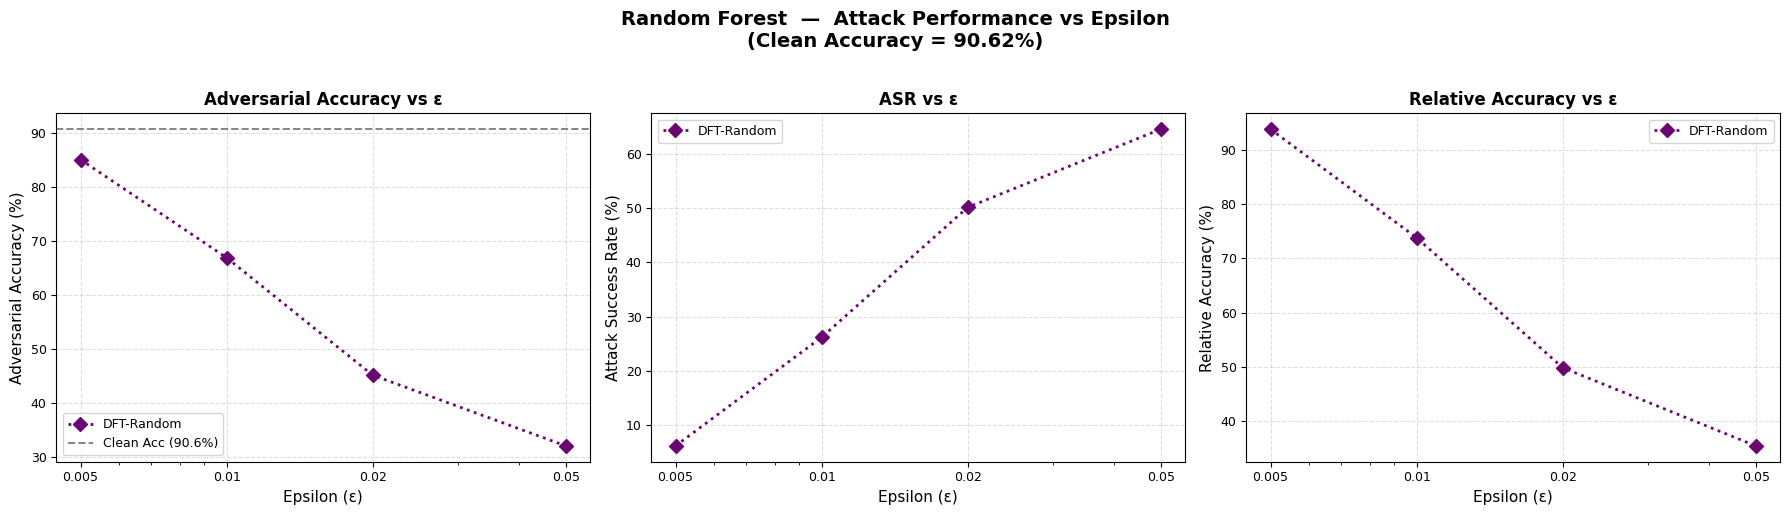

  Saved: /content/results/attack_graphs/Random_Forest_attack_performance.png



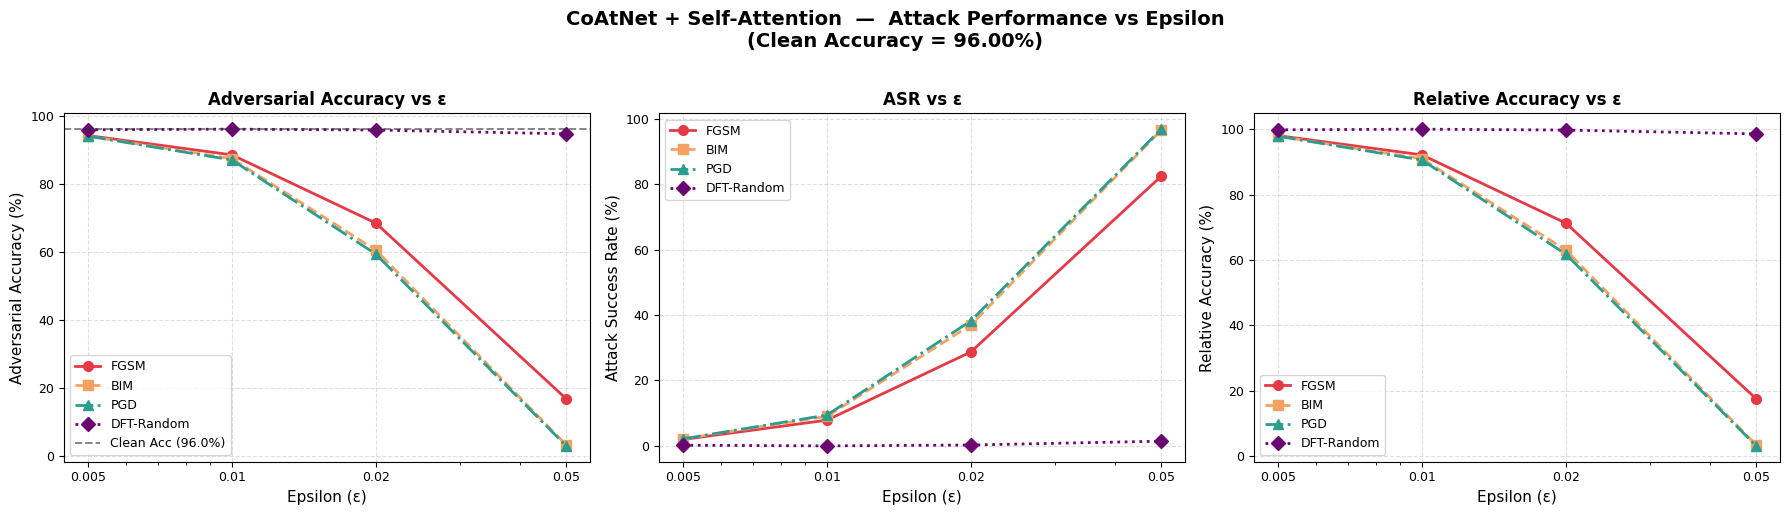

  Saved: /content/results/attack_graphs/CoAtNet_plus_Self-Attention_attack_performance.png



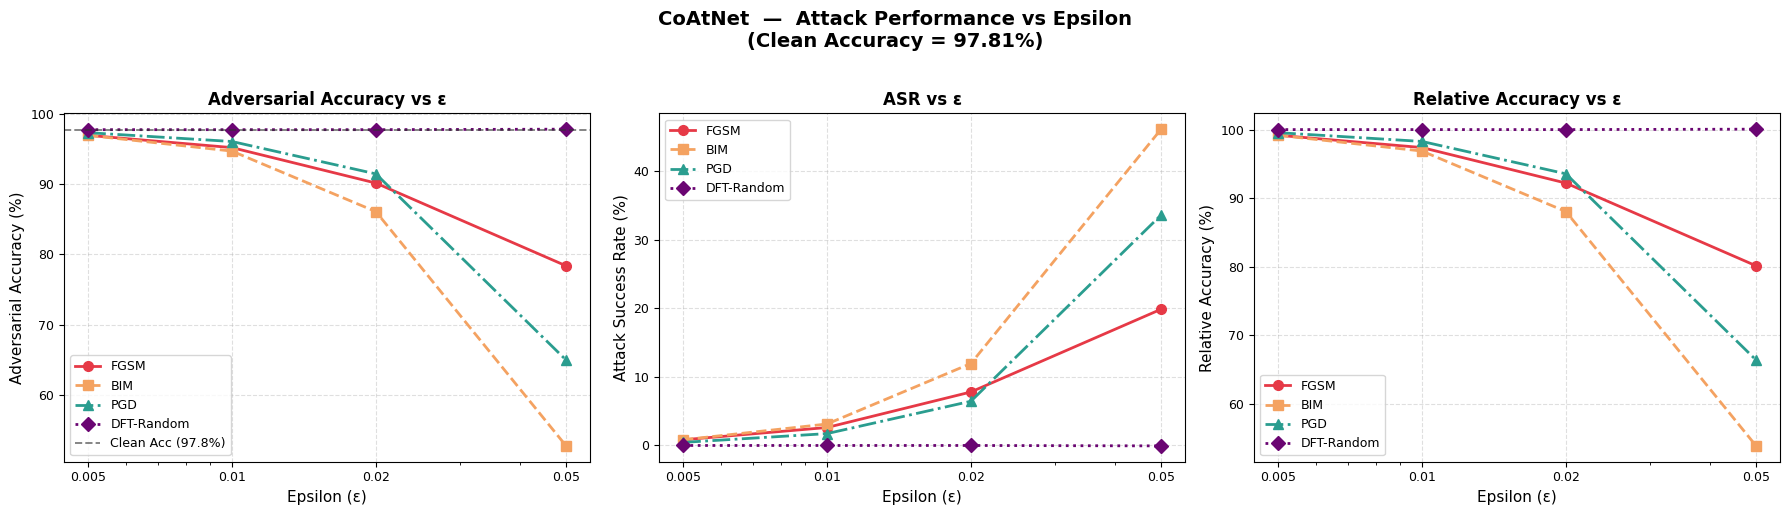

  Saved: /content/results/attack_graphs/CoAtNet_attack_performance.png



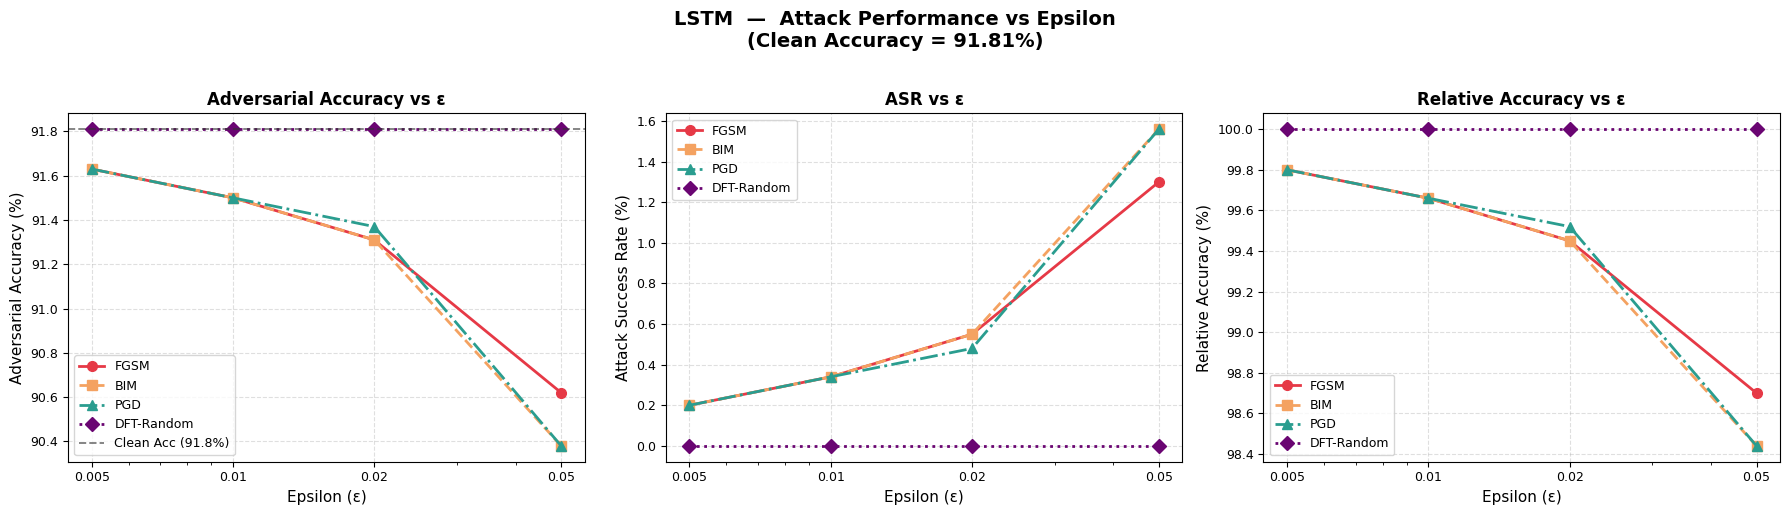

  Saved: /content/results/attack_graphs/LSTM_attack_performance.png



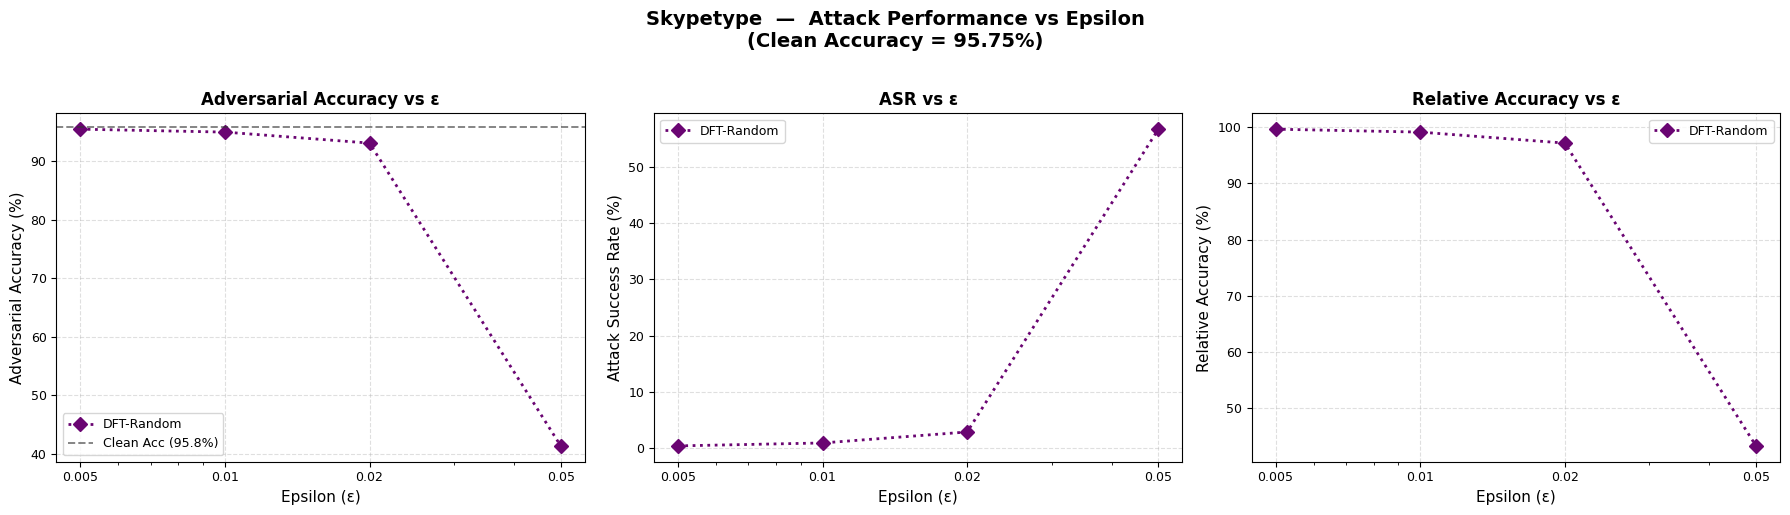

  Saved: /content/results/attack_graphs/Skypetype_attack_performance.png



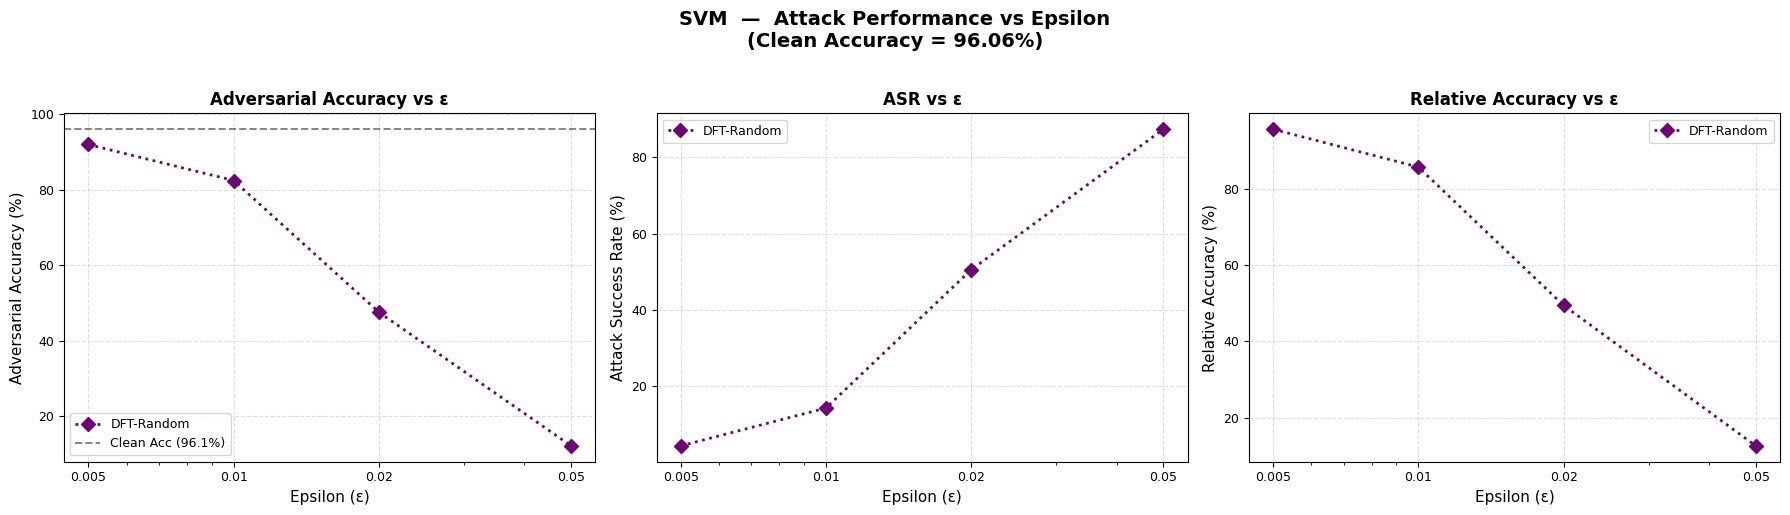

  Saved: /content/results/attack_graphs/SVM_attack_performance.png



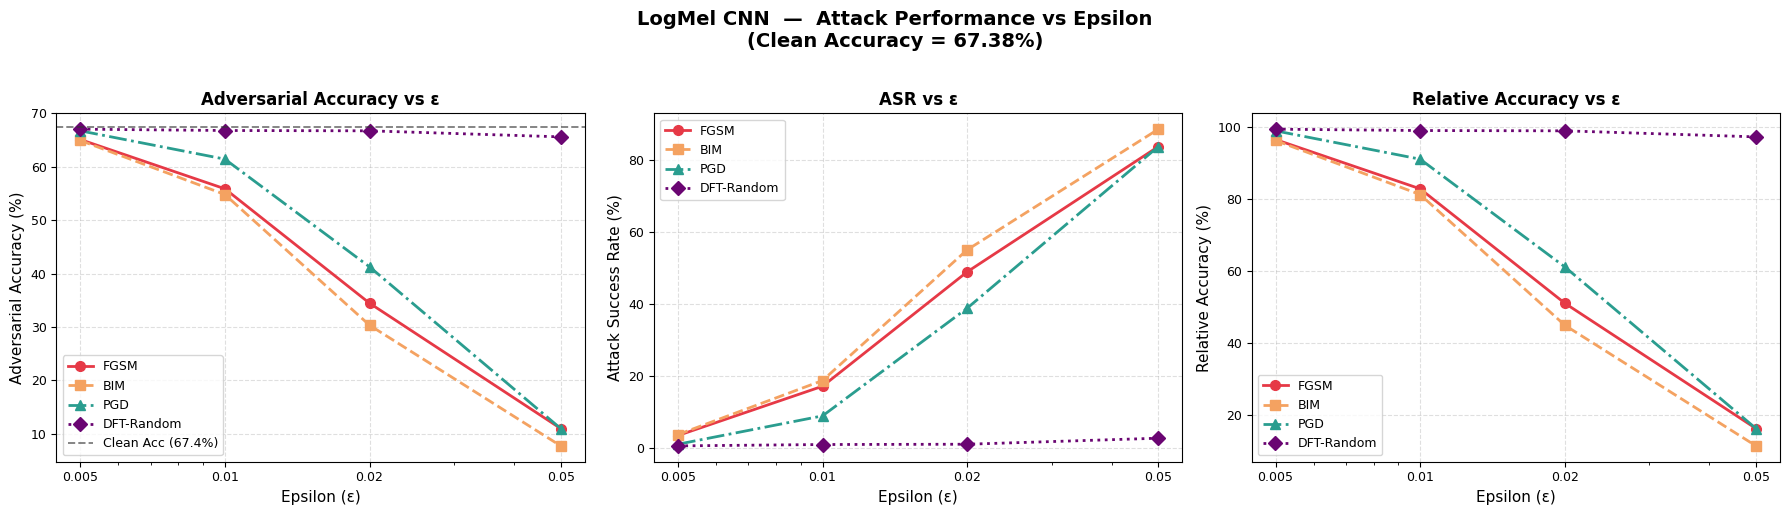

  Saved: /content/results/attack_graphs/LogMel_CNN_attack_performance.png



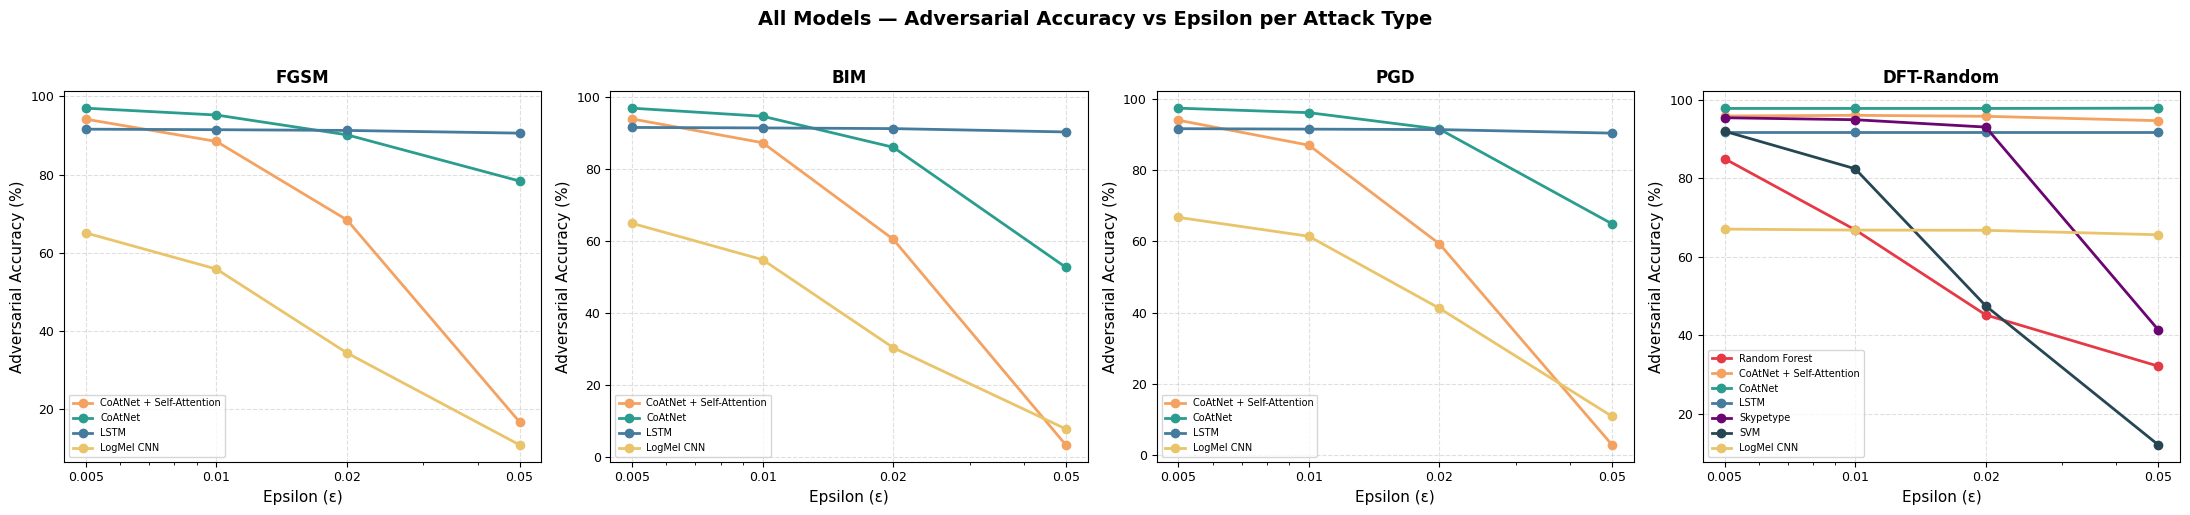

  Saved: /content/results/attack_graphs/all_models_combined_adv_accuracy.png

  All graphs complete.


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ---------------------------------------------------------------
# CSV PATHS
# ---------------------------------------------------------------

csv_paths = {
    "Random Forest"            : "/content/RandomForest_overall_attack_summary.csv",
    "CoAtNet + Self-Attention" : "/content/CoAtNet_SelfAttn_overall_attack_summary.csv",
    "CoAtNet"                  : "/content/CoAtNet_overall_attack_summary.csv",
    "LSTM"                     : "/content/LSTM_overall_attack_summary.csv",
    "Skypetype"                : "/content/Skypetype_overall_attack_summary.csv",
    "SVM"                      : "/content/SVM_overall_attack_summary.csv",
    "LogMel CNN"               : "/content/LogMel_CNN_overall_attack_summary.csv",
}

# ---------------------------------------------------------------
# STYLE CONFIG
# ---------------------------------------------------------------

ATTACK_STYLES = {
    "FGSM"      : {"color": "#E63946", "marker": "o", "linestyle": "-"},
    "BIM"       : {"color": "#F4A261", "marker": "s", "linestyle": "--"},
    "PGD"       : {"color": "#2A9D8F", "marker": "^", "linestyle": "-."},
    "DFT-Random": {"color": "#6A0572", "marker": "D", "linestyle": ":"},
}

ATTACK_ORDER = ["FGSM", "BIM", "PGD", "DFT-Random"]

MODEL_COLORS = {
    "Random Forest"            : "#E63946",
    "CoAtNet + Self-Attention" : "#F4A261",
    "CoAtNet"                  : "#2A9D8F",
    "LSTM"                     : "#457B9D",
    "Skypetype"                : "#6A0572",
    "SVM"                      : "#264653",
    "LogMel CNN"               : "#E9C46A",
}

GRAPH_SAVE_DIR = "/content/results/attack_graphs"
os.makedirs(GRAPH_SAVE_DIR, exist_ok=True)

# ---------------------------------------------------------------
# HELPER — safely apply log scale only when data exists
# ---------------------------------------------------------------

def apply_log_xscale(ax, epsilons):
    """Apply log scale only if all epsilon values are positive."""
    valid = [e for e in epsilons if e > 0]
    if not valid:
        return
    try:
        ax.set_xscale("log")
        ax.set_xticks(valid)
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.set_xticklabels([str(e) for e in valid])
    except ValueError:
        # Fallback to linear if log scale still fails
        ax.set_xscale("linear")
        ax.set_xticks(valid)
        ax.set_xticklabels([str(e) for e in valid])

# ---------------------------------------------------------------
# LOAD ALL CSVs
# ---------------------------------------------------------------

all_frames = []

for model_label, path in csv_paths.items():
    if not os.path.exists(path):
        print(f"[WARNING] Not found - skipping: {model_label}")
        continue
    df               = pd.read_csv(path)
    df["model_name"] = model_label
    df["epsilon"]    = df["epsilon"].astype(float)

    # Normalise attack name — handles both old and new CSVs
    df["attack type"] = df["attack type"].replace({"DFT_Spectral": "DFT-Random"})

    all_frames.append(df)
    print(f"[OK] Loaded: {model_label}")

if not all_frames:
    raise RuntimeError("No CSVs loaded. Check paths.")

df_all       = pd.concat(all_frames, ignore_index=True)
epsilons_all = sorted([e for e in df_all["epsilon"].unique() if e > 0])

print(f"\nEpsilons found : {epsilons_all}")
print(f"Attack types   : {sorted(df_all['attack type'].unique())}")


subplot_cfg = [
    {
        "col"     : "adversarial accuracy",
        "ylabel"  : "Adversarial Accuracy (%)",
        "title"   : "Adversarial Accuracy vs ε",
        "ref_line": True,
    },
    {
        "col"     : "ASR",
        "ylabel"  : "Attack Success Rate (%)",
        "title"   : "ASR vs ε",
        "ref_line": False,
    },
    {
        "col"     : "relative accuracy",
        "ylabel"  : "Relative Accuracy (%)",
        "title"   : "Relative Accuracy vs ε",
        "ref_line": False,
    },
]

for model_name in df_all["model_name"].unique():

    df_model  = df_all[df_all["model_name"] == model_name].copy()
    clean_acc = df_model["Clean accuracy"].iloc[0]
    attacks   = df_model["attack type"].unique()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"{model_name}  —  Attack Performance vs Epsilon\n"
        f"(Clean Accuracy = {clean_acc:.2f}%)",
        fontsize=14, fontweight="bold", y=1.02
    )

    for cfg, ax in zip(subplot_cfg, axes):

        has_data = False

        for attack in ATTACK_ORDER:

            if attack not in attacks:
                continue

            df_attack = (
                df_model[df_model["attack type"] == attack]
                .groupby("epsilon")[cfg["col"]]
                .mean()
                .reset_index()
                .sort_values("epsilon")
            )

            # Guard: drop non-positive epsilons before log scale
            df_attack = df_attack[df_attack["epsilon"] > 0]

            if df_attack.empty:
                continue

            style = ATTACK_STYLES.get(attack, {"color": "grey", "marker": "x", "linestyle": "-"})

            ax.plot(
                df_attack["epsilon"],
                df_attack[cfg["col"]],
                color     = style["color"],
                marker    = style["marker"],
                linestyle = style["linestyle"],
                linewidth = 2,
                markersize= 7,
                label     = attack,
            )
            has_data = True

        # Clean accuracy reference line — only on adv accuracy subplot
        if cfg["ref_line"] and has_data:
            ax.axhline(
                y         = clean_acc,
                color     = "#333333",
                linestyle = "--",
                linewidth = 1.4,
                alpha     = 0.6,
                label     = f"Clean Acc ({clean_acc:.1f}%)",
            )

        if has_data:
            apply_log_xscale(ax, epsilons_all)
        else:
            ax.text(
                0.5, 0.5, "No data available",
                transform = ax.transAxes,
                ha="center", va="center",
                fontsize=11, color="grey"
            )

        ax.set_xlabel("Epsilon (ε)", fontsize=11)
        ax.set_ylabel(cfg["ylabel"], fontsize=11)
        ax.set_title(cfg["title"], fontsize=12, fontweight="bold")
        ax.legend(fontsize=9, loc="best")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.tick_params(axis="both", labelsize=9)

    plt.tight_layout()

    safe_name = model_name.replace(" ", "_").replace("+", "plus")
    save_path = os.path.join(GRAPH_SAVE_DIR, f"{safe_name}_attack_performance.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved: {save_path}\n")


attacks_present = [a for a in ATTACK_ORDER if a in df_all["attack type"].unique()]

fig, axes = plt.subplots(1, len(attacks_present), figsize=(22, 5), sharey=False)

if len(attacks_present) == 1:
    axes = [axes]

fig.suptitle(
    "All Models — Adversarial Accuracy vs Epsilon per Attack Type",
    fontsize=14, fontweight="bold", y=1.02
)

for ax, attack in zip(axes, attacks_present):

    df_attack_all = df_all[df_all["attack type"] == attack]
    has_data      = False

    for model_name in df_all["model_name"].unique():

        df_m = (
            df_attack_all[df_attack_all["model_name"] == model_name]
            .groupby("epsilon")["adversarial accuracy"]
            .mean()
            .reset_index()
            .sort_values("epsilon")
        )

        df_m = df_m[df_m["epsilon"] > 0]

        if df_m.empty:
            continue

        ax.plot(
            df_m["epsilon"],
            df_m["adversarial accuracy"],
            color     = MODEL_COLORS.get(model_name, "grey"),
            marker    = "o",
            linewidth = 2,
            markersize= 6,
            label     = model_name,
        )
        has_data = True

    if has_data:
        apply_log_xscale(ax, epsilons_all)

    ax.set_xlabel("Epsilon (ε)", fontsize=11)
    ax.set_ylabel("Adversarial Accuracy (%)", fontsize=11)
    ax.set_title(f"{attack}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=7, loc="best")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.tick_params(axis="both", labelsize=9)

plt.tight_layout()

combined_save = os.path.join(GRAPH_SAVE_DIR, "all_models_combined_adv_accuracy.png")
plt.savefig(combined_save, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"  Saved: {combined_save}")
print("\n  All graphs complete.")

Blockchain Section

In [ ]:
best_model_record = {
    "model_name"       : best_model,
    "clean_accuracy"   : round(float(best_row["clean_accuracy"]),    2),
    "mean_adv_accuracy": round(float(best_row["mean_adv_accuracy"]), 2),
    "mean_asr"         : round(float(best_row["mean_asr"]),          2),
    "robustness_score" : round(float(best_row["robustness_score"]),  2),
    "rank"             : int(best_row["rank"]),
    "timestamp"        : datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC"),
}

best_model_csv_path = "/content/results/best_model_summary.csv"
pd.DataFrame([best_model_record]).to_csv(best_model_csv_path, index=False)

print("  Record contents:")
for k, v in best_model_record.items():
    print(f"    {k:<22}: {v}")
print(f"\n  Saved to: {best_model_csv_path}")

  Record contents:
    model_name            : LSTM
    clean_accuracy        : 91.81
    mean_adv_accuracy     : 91.38
    mean_asr              : 0.48
    robustness_score      : 91.33
    rank                  : 1
    timestamp             : 2026-03-20 03:19:23 UTC

  Saved to: /content/results/best_model_summary.csv


/tmp/ipykernel_605/2866853899.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp"        : datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC"),


In [ ]:
def get_file_hash(filepath):
    with open(filepath, "rb") as f:
        return hashlib.sha256(f.read()).hexdigest()

file_hash = get_file_hash(best_model_csv_path)

print("  SHA-256 FILE HASH")
print(f"  File  : {best_model_csv_path}")
print(f"  Hash  : {file_hash}")

  SHA-256 FILE HASH
  File  : /content/results/best_model_summary.csv
  Hash  : 1dccfbe258e944fb059330e504ffea00da6220f19b5eda08782881252bab1748


In [ ]:
# RPC_URL = "INSERT RPC URL"
w3 = Web3(Web3.HTTPProvider(RPC_URL))

if w3.is_connected():
    print(f"  Connected    : True")
    print(f"  Chain ID     : {w3.eth.chain_id}")
    print(f"  Latest Block : {w3.eth.block_number}")
else:
    raise ConnectionError(
        "Web3 connection failed.\n"
        "Check your RPC_URL - make sure it is a valid Infura/Alchemy Sepolia endpoint."
    )

  Connected    : True
  Chain ID     : 11155111
  Latest Block : 10481127


In [ ]:
# wallet_address = "wallet_address"
# private_key    = "private_key"

data_payload = w3.to_hex(text=file_hash)

nonce = w3.eth.get_transaction_count(wallet_address)

tx = {
    "to"       : wallet_address,          # self-send - data-only transaction
    "value"    : 0,                        # no ETH transferred
    "gas"      : 200000,
    "gasPrice" : w3.to_wei("10", "gwei"),
    "nonce"    : nonce,
    "data"     : data_payload,             # SHA-256 hash stored here
    "chainId"  : w3.eth.chain_id,
}

signed_tx   = w3.eth.account.sign_transaction(tx, private_key)
tx_hash     = w3.eth.send_raw_transaction(signed_tx.raw_transaction)
tx_hash_hex = w3.to_hex(tx_hash)

print(f"  Model             : {best_model}")
print(f"  Clean Accuracy    : {best_model_record['clean_accuracy']}%")
print(f"  File Hash (SHA256): {file_hash}")
print(f"  Transaction Hash  : {tx_hash_hex}")
print(f"\n  View on Etherscan : https://sepolia.etherscan.io/tx/{tx_hash_hex}")

  Model             : LSTM
  Clean Accuracy    : 91.81%
  File Hash (SHA256): 1dccfbe258e944fb059330e504ffea00da6220f19b5eda08782881252bab1748
  Transaction Hash  : 0xd8aa6c9a68683b7ced46fbf29c73ef034f1a3bbf22da81e38f39f5a3d03da634

  View on Etherscan : https://sepolia.etherscan.io/tx/0xd8aa6c9a68683b7ced46fbf29c73ef034f1a3bbf22da81e38f39f5a3d03da634


In [ ]:
best_model_record["file_hash"]        = file_hash
best_model_record["transaction_hash"] = tx_hash_hex
best_model_record["etherscan_url"]    = f"https://sepolia.etherscan.io/tx/{tx_hash_hex}"

record_path = "/content/results/best_model_blockchain_record.json"
with open(record_path, "w") as f:
    json.dump(best_model_record, f, indent=4)

print(f"\n  Full record saved : {record_path}")


  Full record saved : /content/results/best_model_blockchain_record.json


In [ ]:
retrieved_tx  = w3.eth.get_transaction(tx_hash_hex)
stored_data   = retrieved_tx["input"]
stored_hash   = w3.to_text(stored_data)

print(f"  Transaction Hash  : {tx_hash_hex}")
print(f"  Raw Stored Data   : {stored_data}")
print(f"  Decoded Hash      : {stored_hash}")
print(f"  Original Hash     : {file_hash}")
print(f"\n  Result : {'VERIFIED - hashes match. Record is tamper-proof.' if stored_hash == file_hash else 'MISMATCH - stored hash does not match. Data may have been altered.'}")

  Transaction Hash  : 0xd8aa6c9a68683b7ced46fbf29c73ef034f1a3bbf22da81e38f39f5a3d03da634
  Raw Stored Data   : b'1dccfbe258e944fb059330e504ffea00da6220f19b5eda08782881252bab1748'
  Decoded Hash      : 1dccfbe258e944fb059330e504ffea00da6220f19b5eda08782881252bab1748
  Original Hash     : 1dccfbe258e944fb059330e504ffea00da6220f19b5eda08782881252bab1748

  Result : VERIFIED - hashes match. Record is tamper-proof.


In [ ]:
print(f"  Best Model        : {best_model}")
print(f"  Clean Accuracy    : {best_model_record['clean_accuracy']}%")
print(f"  Robustness Score  : {best_model_record['robustness_score']}%")
print(f"  Mean ASR          : {best_model_record['mean_asr']}%")
print(f"  SHA-256 Hash      : {file_hash}")
print(f"  Transaction Hash  : {tx_hash_hex}")
print(f"  Etherscan URL     : {best_model_record['etherscan_url']}")
print(f"  Timestamp         : {best_model_record['timestamp']}")

print("  All results saved to /content/results/")


  Best Model        : LSTM
  Clean Accuracy    : 91.81%
  Robustness Score  : 91.33%
  Mean ASR          : 0.48%
  SHA-256 Hash      : 1dccfbe258e944fb059330e504ffea00da6220f19b5eda08782881252bab1748
  Transaction Hash  : 0xd8aa6c9a68683b7ced46fbf29c73ef034f1a3bbf22da81e38f39f5a3d03da634
  Etherscan URL     : https://sepolia.etherscan.io/tx/0xd8aa6c9a68683b7ced46fbf29c73ef034f1a3bbf22da81e38f39f5a3d03da634
  Timestamp         : 2026-03-20 03:19:23 UTC
  All results saved to /content/results/
